In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Machine Learning Case Study – Review 1

## NYC Taxi Fare Prediction and Classification

### Problem Statement
The objective of this case study is to develop and compare multiple machine learning models for predicting taxi fare amounts using trip-related features.

### Tracks Covered
- Regression: Predicting the taxi fare amount
- Classification Part A: Categorizing taxi fares into Low, Medium, and High

In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


In [151]:
# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [155]:
# ==========================================
# 1. DATA LOADING & AUDIT
# ==========================================

import pandas as pd

# Path to the locally downloaded dataset
file_path = "yellow_tripdata_2023-01.parquet"

print("Loading NYC TLC Parquet data from local file...")

# Load the locally downloaded dataset
raw_df = pd.read_parquet(file_path)

# Randomly sample 100,000 records for computational efficiency
raw_df = raw_df.sample(
    n=100000,
    random_state=RANDOM_STATE
)

print("--- Raw Dataset Audit ---")
print(f"Sampled Dataset Shape: {raw_df.shape}")

print("\nData Types:")
print(raw_df.dtypes)

print("\nMissing Values Count:")
print(raw_df.isnull().sum())

print("\nDuplicate Rows Count:")
print(raw_df.duplicated().sum())

print("\nFare Amount Summary:")
print(raw_df["fare_amount"].describe())

Loading NYC TLC Parquet data from local file...
--- Raw Dataset Audit ---
Sampled Dataset Shape: (100000, 19)

Data Types:
VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
dtype: object

Missing Values Count:
VendorID                    0
tpep_pickup_datetime        0
tpep_dropoff_datetim

In [156]:
print("\n--- First 5 Rows of the Dataset ---")
raw_df.head()


--- First 5 Rows of the Dataset ---


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
2790731,2,2023-01-29 17:52:02,2023-01-29 17:56:43,1.0,1.17,1.0,N,262,74,2,7.2,0.0,0.5,0.00,0.0,1.0,11.20,2.5,0.0
666153,1,2023-01-08 15:57:24,2023-01-08 16:02:47,1.0,0.90,1.0,N,229,237,2,6.5,2.5,0.5,0.00,0.0,1.0,10.50,2.5,0.0
1985683,2,2023-01-21 19:38:01,2023-01-21 19:45:02,1.0,0.95,1.0,N,45,261,1,7.9,0.0,0.5,2.38,0.0,1.0,14.28,2.5,0.0
2154231,2,2023-01-23 16:07:31,2023-01-23 16:26:46,5.0,0.88,1.0,N,237,141,1,16.3,2.5,0.5,1.50,0.0,1.0,24.30,2.5,0.0
2493619,2,2023-01-26 21:21:08,2023-01-26 21:24:48,2.0,1.03,1.0,N,229,140,1,6.5,1.0,0.5,2.30,0.0,1.0,13.80,2.5,0.0


In [157]:
print(raw_df.columns.tolist())

['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


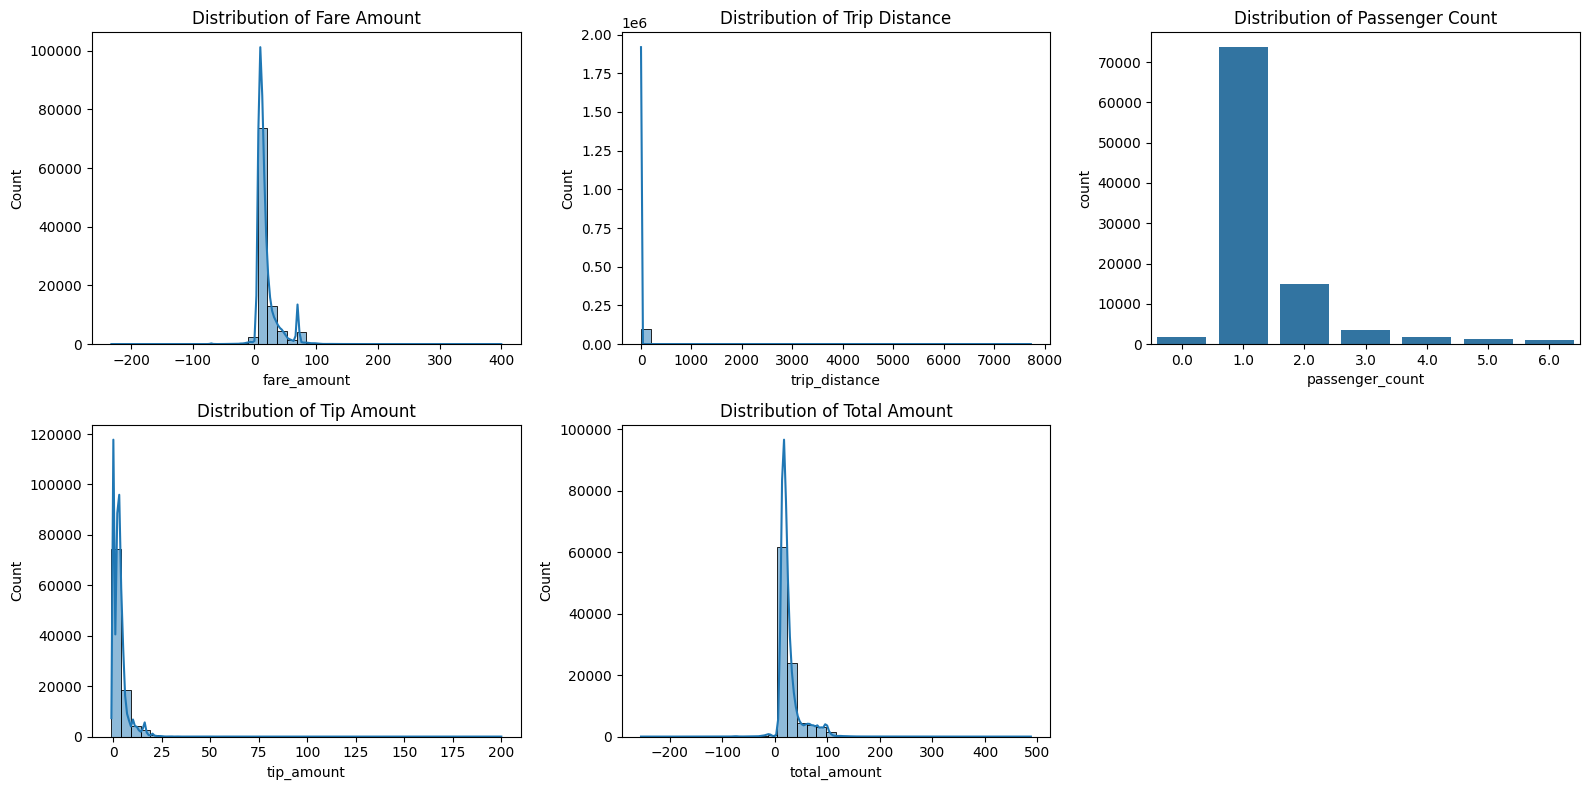

In [158]:
# ==========================================
# EDA: NUMERICAL FEATURE DISTRIBUTIONS
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# 1. Fare Amount
sns.histplot(raw_df['fare_amount'], bins=40, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Fare Amount')

# 2. Trip Distance
sns.histplot(raw_df['trip_distance'], bins=40, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Trip Distance')

# 3. Passenger Count
sns.countplot(data=raw_df, x='passenger_count', ax=axes[0, 2])
axes[0, 2].set_title('Distribution of Passenger Count')

# 4. Tip Amount
sns.histplot(raw_df['tip_amount'], bins=40, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Tip Amount')

# 5. Total Amount
sns.histplot(raw_df['total_amount'], bins=40, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Total Amount')

# Remove unused subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

### Key Insights from Numerical Feature Distributions

- **Fare Amount:** Most trips have relatively lower fare amounts, with the distribution concentrated near the lower values. A long right tail and a few extreme values are also visible.

- **Trip Distance:** The majority of trips have short travel distances, while a small number of trips have extremely large distances. This indicates a highly right-skewed distribution and the possible presence of outliers.

- **Passenger Count:** Most trips involve **one passenger**, followed by smaller numbers of trips with two or more passengers. Higher passenger counts occur much less frequently.

- **Tip Amount:** Most tip amounts are concentrated at lower values, while a smaller number of trips have very high tips. The distribution is strongly right-skewed.

- **Total Amount:** Most trips have lower total amounts, with fewer trips having significantly higher values. The presence of extreme values suggests that further outlier analysis is required.

Overall, the numerical features show **skewed distributions and potential extreme values**, indicating the need for appropriate data cleaning and preprocessing before model development.

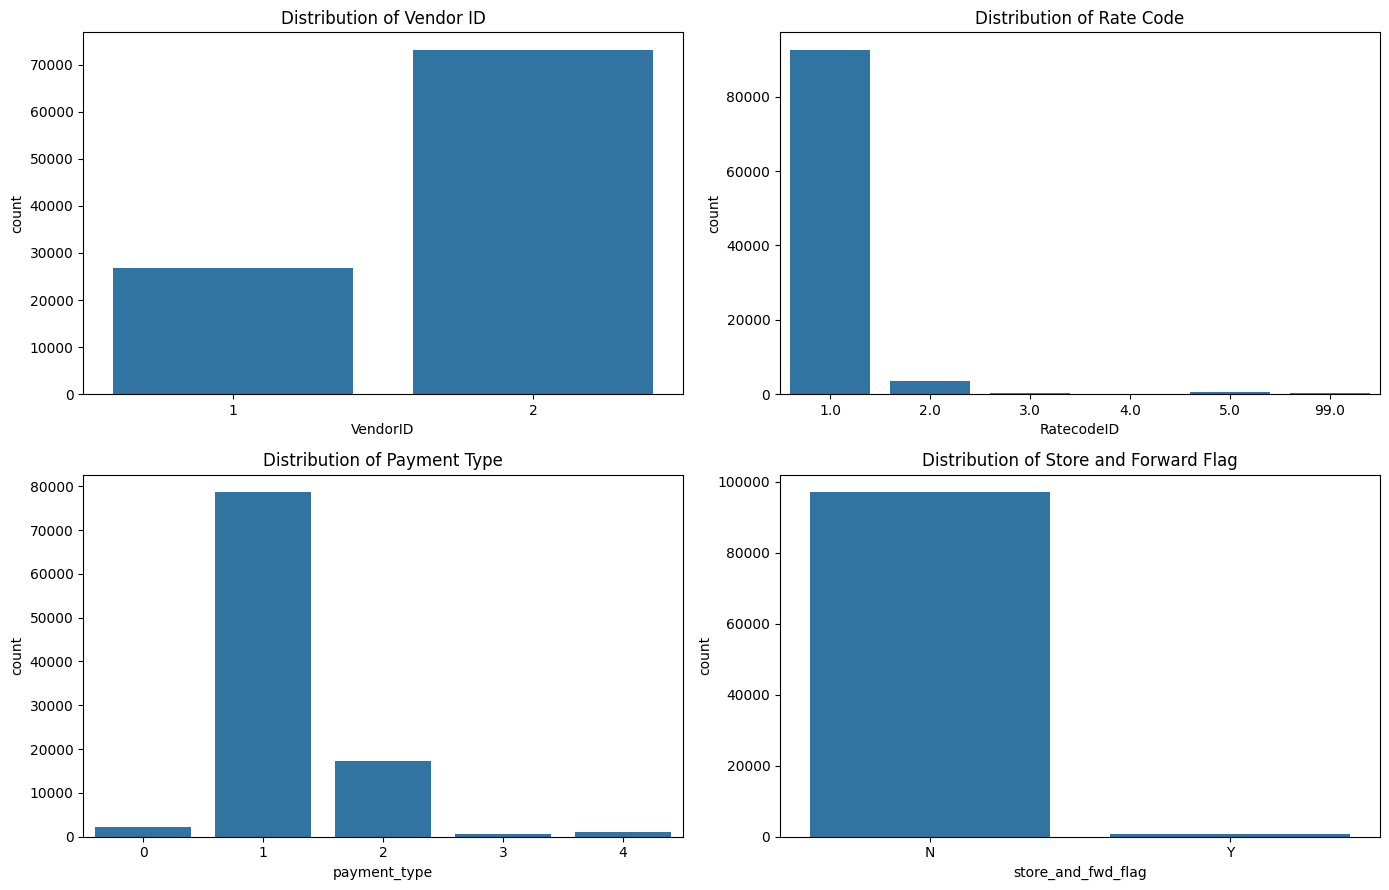

In [130]:
# ==========================================
# EDA: CATEGORICAL FEATURE DISTRIBUTIONS
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Vendor ID
sns.countplot(data=raw_df, x='VendorID', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Vendor ID')

# 2. Rate Code ID
sns.countplot(data=raw_df, x='RatecodeID', ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Rate Code')

# 3. Payment Type
sns.countplot(data=raw_df, x='payment_type', ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Payment Type')

# 4. Store and Forward Flag
sns.countplot(data=raw_df, x='store_and_fwd_flag', ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Store and Forward Flag')

plt.tight_layout()
plt.show()

### Key Insights from Categorical Feature Distributions

- **VendorID:** Vendor 2 has substantially more trip records than Vendor 1, indicating that Vendor 2 accounts for the majority of trips in this dataset.

- **RatecodeID:** Rate Code 1 is overwhelmingly the most frequently used rate category. The other rate codes occur much less frequently.

- **Payment Type:** Payment Type 1 is the most commonly used payment method, followed by Payment Type 2. The remaining payment types have very few records.

- **Store and Forward Flag:** The majority of trips have the value **'N'**, while only a very small number of trips have the value **'Y'**. This shows a highly imbalanced distribution for this feature.

Overall, the categorical features show clear differences in category frequencies, with several variables being highly dominated by one category. These patterns should be considered during preprocessing and model development.

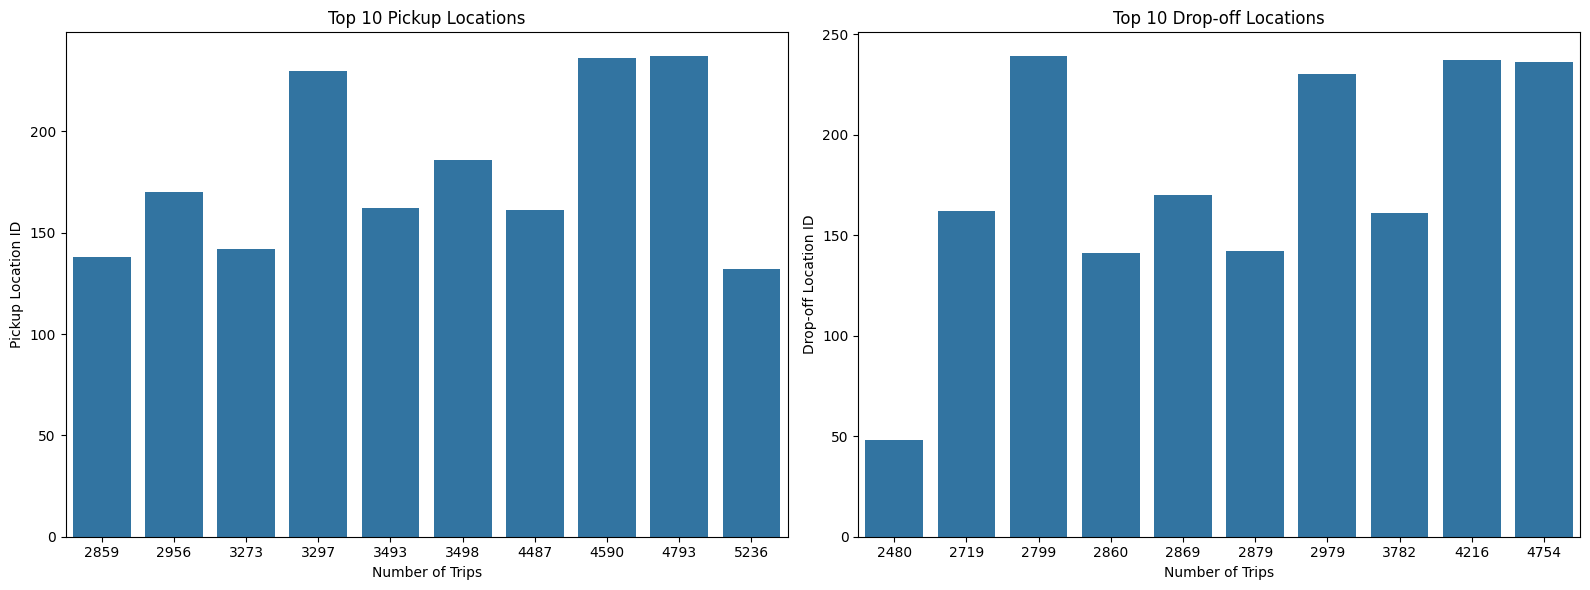

In [131]:
# ==========================================
# EDA: TOP PICKUP AND DROPOFF LOCATIONS
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 Pickup Locations
top_pickup = raw_df['PULocationID'].value_counts().head(10)

sns.barplot(
    x=top_pickup.values,
    y=top_pickup.index,
    ax=axes[0]
)

axes[0].set_title('Top 10 Pickup Locations')
axes[0].set_xlabel('Number of Trips')
axes[0].set_ylabel('Pickup Location ID')


# Top 10 Drop-off Locations
top_dropoff = raw_df['DOLocationID'].value_counts().head(10)

sns.barplot(
    x=top_dropoff.values,
    y=top_dropoff.index,
    ax=axes[1]
)

axes[1].set_title('Top 10 Drop-off Locations')
axes[1].set_xlabel('Number of Trips')
axes[1].set_ylabel('Drop-off Location ID')

plt.tight_layout()
plt.show()

### Key Insights from Pickup and Drop-off Location Analysis

- The visualization shows that taxi trips are concentrated across a limited set of frequently used pickup and drop-off location IDs.

- For **pickup locations**, Location IDs **4590 and 4793** have the highest number of trips among the displayed locations, while the other top locations also show relatively similar trip frequencies.

- For **drop-off locations**, Location IDs **2719, 4216, and 4754** appear to have the highest trip frequencies among the top 10 locations.

- The differences between the most frequently used pickup and drop-off locations indicate that certain areas experience higher taxi activity than others.

- These location-based patterns suggest that **pickup and drop-off location features can provide useful information for analyzing and predicting taxi demand**.

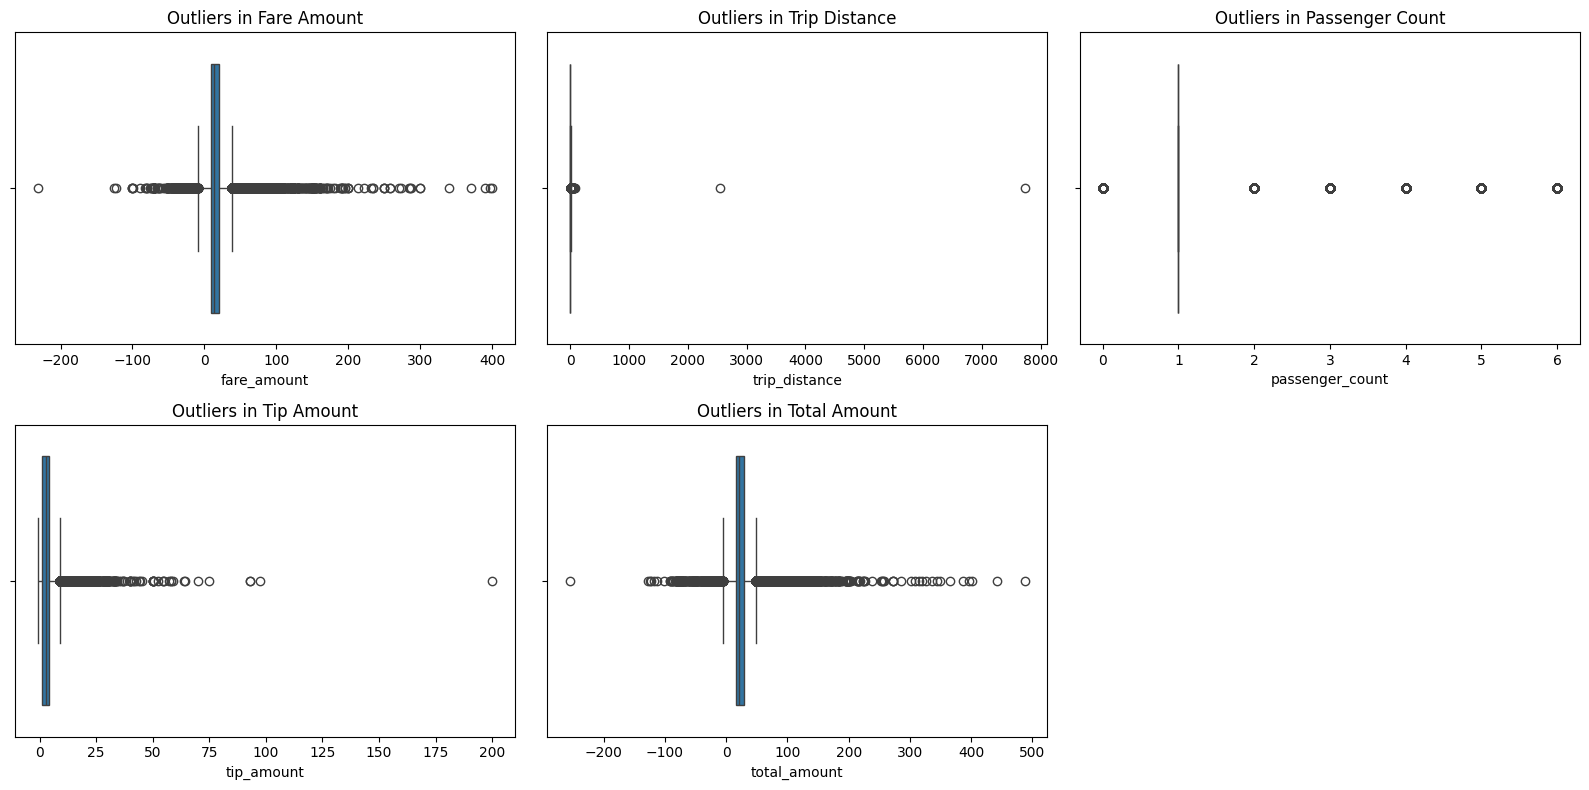

In [132]:
# ==========================================
# EDA: BOX PLOTS FOR OUTLIER DETECTION
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# 1. Fare Amount
sns.boxplot(x=raw_df['fare_amount'], ax=axes[0, 0])
axes[0, 0].set_title('Outliers in Fare Amount')

# 2. Trip Distance
sns.boxplot(x=raw_df['trip_distance'], ax=axes[0, 1])
axes[0, 1].set_title('Outliers in Trip Distance')

# 3. Passenger Count
sns.boxplot(x=raw_df['passenger_count'], ax=axes[0, 2])
axes[0, 2].set_title('Outliers in Passenger Count')

# 4. Tip Amount
sns.boxplot(x=raw_df['tip_amount'], ax=axes[1, 0])
axes[1, 0].set_title('Outliers in Tip Amount')

# 5. Total Amount
sns.boxplot(x=raw_df['total_amount'], ax=axes[1, 1])
axes[1, 1].set_title('Outliers in Total Amount')

# Remove unused subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

## Outlier Detection

Boxplots were used to identify potential outliers in the important numerical features of the dataset.

The plots show the presence of extreme values in **Fare Amount, Trip Distance, Passenger Count, Tip Amount, and Total Amount**. In particular, Fare Amount, Trip Distance, Tip Amount, and Total Amount contain several unusually high or low values compared to the majority of observations.

These potential outliers were further considered during the data cleaning process to ensure that unrealistic or invalid values did not negatively affect the machine learning models.

In [10]:
# ==========================================
# 2. DATA CLEANING
# ==========================================
df = raw_df.copy()

# Datetime Parsing & Duration
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
df['trip_duration_min'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60.0

# No duplicate rows were found during the dataset audit

# Outlier Filtering
df = df[
    (df['trip_distance'] > 0.1) & (df['trip_distance'] < 100) &
    (df['fare_amount'] > 2.5) & (df['fare_amount'] < 300) &
    (df['trip_duration_min'] > 1.0) & (df['trip_duration_min'] < 180) &
    (df['passenger_count'] > 0) & (df['passenger_count'] <= 6)
].copy()

# Fill missing numerical values using the median
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(
    df['congestion_surcharge'].median()
)

df['airport_fee'] = df['airport_fee'].fillna(
    df['airport_fee'].median()
)

# Fill missing categorical values using the most frequent category
df['RatecodeID'] = df['RatecodeID'].fillna(
    df['RatecodeID'].mode()[0]
).astype(str)

df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna(
    df['store_and_fwd_flag'].mode()[0]
)

# Convert categorical ID column to string
df['payment_type'] = df['payment_type'].astype(str)

print("\n--- Data Cleaning Summary ---")
print(f"Records after cleaning: {df.shape[0]}")
print(f"Records removed: {raw_df.shape[0] - df.shape[0]}")

print("\nRemaining Missing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


--- Data Cleaning Summary ---
Records after cleaning: 93604
Records removed: 6396

Remaining Missing Values:
Series([], dtype: int64)


In [11]:
# ==========================================
# 3. FEATURE ENGINEERING
# ==========================================
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['day_of_week'] = df['tpep_pickup_datetime'].dt.day_name()
df['is_weekend'] = df['tpep_pickup_datetime'].dt.dayofweek.isin([5, 6]).astype(int)

df['PULocationID'] = df['PULocationID'].astype(str)
df['DOLocationID'] = df['DOLocationID'].astype(str)

X = df[['PULocationID', 'DOLocationID', 'day_of_week',
        'passenger_count', 'trip_distance', 'trip_duration_min',
        'pickup_hour', 'is_weekend']]
y = df['fare_amount']

num_features = ['passenger_count', 'trip_distance', 'trip_duration_min', 'pickup_hour', 'is_weekend']
cat_features = ['PULocationID', 'DOLocationID', 'day_of_week']

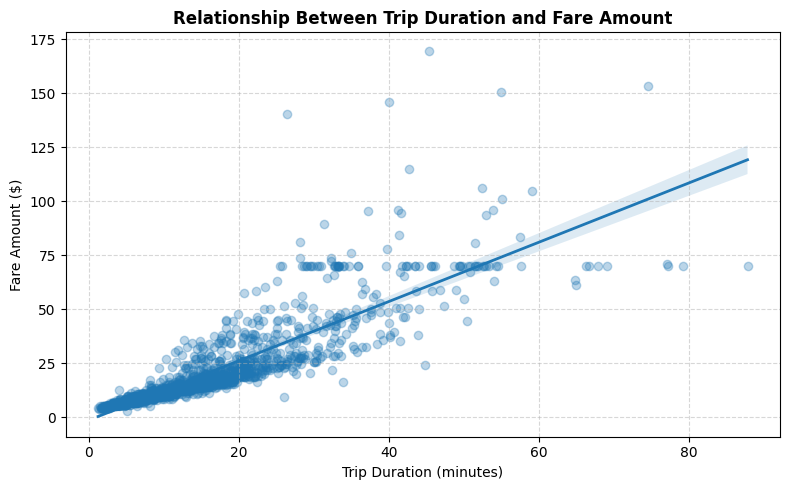

In [17]:
# EXPLORATORY DATA ANALYSIS (EDA)

plt.figure(figsize=(8, 5))

# Sample 2,000 records for clearer visualization
sns.regplot(
    data=df.sample(2000, random_state=RANDOM_STATE),
    x='trip_duration_min',
    y='fare_amount',
    scatter_kws={'alpha': 0.3},
    line_kws={'linewidth': 2}
)

plt.title('Relationship Between Trip Duration and Fare Amount',
          fontsize=12, fontweight='bold')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Relationship Between Trip Duration and Fare Amount

The scatter plot shows a clear positive relationship between trip duration and fare amount. As the duration of a trip increases, the fare amount generally increases.

However, some points deviate from the overall trend, indicating the presence of unusual trips or potential outliers. Overall, trip duration appears to be an important feature for predicting fare amount.

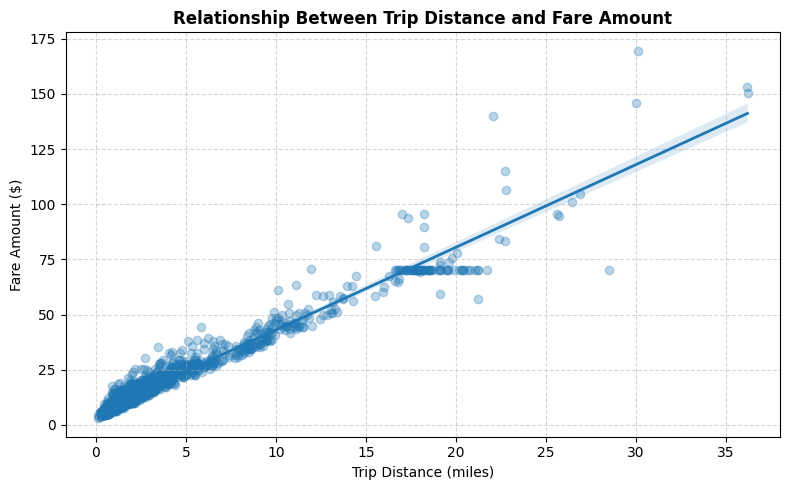

In [18]:
# EXPLORATORY DATA ANALYSIS (EDA)

plt.figure(figsize=(8, 5))

# Sample 2,000 records for clearer visualization
sns.regplot(
    data=df.sample(2000, random_state=RANDOM_STATE),
    x='trip_distance',
    y='fare_amount',
    scatter_kws={'alpha': 0.3},
    line_kws={'linewidth': 2}
)

plt.title('Relationship Between Trip Distance and Fare Amount',
          fontsize=12, fontweight='bold')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Relationship Between Trip Distance and Fare Amount

The scatter plot shows a strong positive relationship between trip distance and fare amount. Longer trips generally result in higher fare amounts.

Although some observations deviate from the overall trend, the relationship is clearly positive. This indicates that trip distance is an important feature for predicting taxi fare amount.

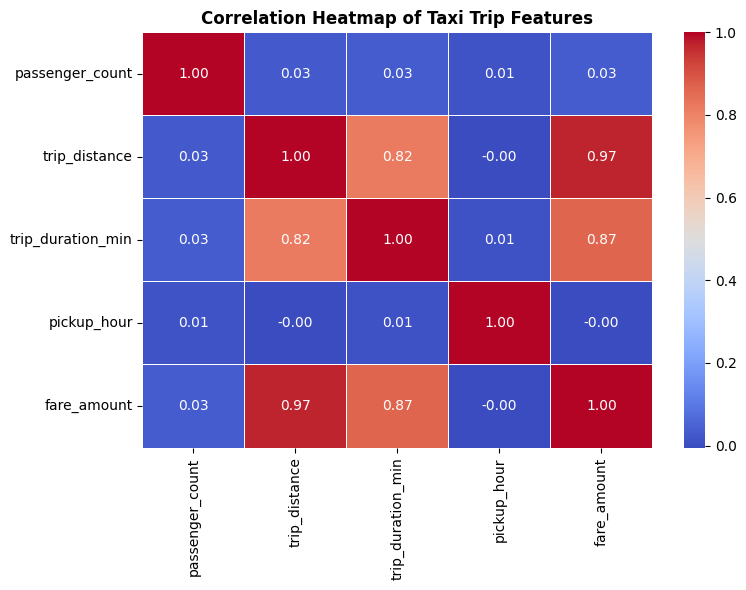

In [10]:
plt.figure(figsize=(8, 6))

num_cols = ['passenger_count', 'trip_distance', 'trip_duration_min', 'pickup_hour', 'fare_amount']
corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Taxi Trip Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Correlation Analysis

The correlation heatmap was used to examine the relationships between important numerical features.

Trip distance shows a very strong positive correlation with fare amount (approximately 0.97), indicating that fare amount generally increases as trip distance increases. Trip duration also has a strong positive correlation with fare amount (approximately 0.87).

Trip distance and trip duration are also strongly correlated (approximately 0.82). Passenger count and pickup hour show very weak correlations with fare amount.

Overall, trip distance and trip duration appear to be the most important numerical features for predicting taxi fare amount.

In [19]:
# ==========================================
# 4. PREPROCESSING & TRAIN-TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)

#Categorical feature encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_features)
    ]
)

# Fit ONLY on Training Data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\n--- Pipeline Status ---")
print(f"Cleaned Dataset Shape: {df.shape}")
print(f"X_train Shape: {X_train_processed.shape}")
print(f"X_test Shape: {X_test_processed.shape}")


--- Pipeline Status ---
Cleaned Dataset Shape: (93604, 23)
X_train Shape: (74883, 450)
X_test Shape: (18721, 450)


C:\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [20]:
# ==========================================
# 5. DIMENSIONALITY REDUCTION USING PCA
# ==========================================

from sklearn.decomposition import PCA

# Apply PCA while retaining 95% of the variance
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)

# Fit PCA only on training data
X_train_reduced = pca.fit_transform(X_train_processed)

# Apply the same transformation to test data
X_test_reduced = pca.transform(X_test_processed)

print("\n--- Dimensionality Reduction Summary ---")
print(f"Original number of features: {X_train_processed.shape[1]}")
print(f"Reduced number of features: {X_train_reduced.shape[1]}")
print(f"Explained variance retained: {pca.explained_variance_ratio_.sum():.4f}")


--- Dimensionality Reduction Summary ---
Original number of features: 450
Reduced number of features: 75
Explained variance retained: 0.9509


In [21]:
# Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

# Train Model
lr = LinearRegression()
lr.fit(X_train_reduced, y_train)

# Predict
y_pred_lr = lr.predict(X_test_reduced)

# Evaluate
lr_r2 = r2_score(y_test, y_pred_lr)
lr_rmse = root_mean_squared_error(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)

print("Model 1: Linear Regression")
print(f"R² Score: {lr_r2:.4f} | RMSE: {lr_rmse:.4f} | MAE: {lr_mae:.4f}")

Model 1: Linear Regression
R² Score: 0.9612 | RMSE: 3.2678 | MAE: 1.2460


In [75]:
# ==========================================
# MODEL 2: RIDGE REGRESSION
# ==========================================

from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
import pandas as pd

# Different alpha values to tune
alpha_values = [0.01, 0.1, 1.0, 10.0, 100.0]

# Store results
ridge_tuning_results = []

for alpha in alpha_values:

    # Create Ridge model
    ridge_model = Ridge(alpha=alpha)

    # Train model
    ridge_model.fit(X_train_reduced, y_train)

    # Predict
    y_pred = ridge_model.predict(X_test_reduced)

    # Evaluate
    r2 = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    # Store results
    ridge_tuning_results.append({
        'Alpha': alpha,
        'R2 Score': r2,
        'RMSE': rmse,
        'MAE': mae
    })


# Convert results to DataFrame
ridge_tuning_results = pd.DataFrame(ridge_tuning_results)

# Sort by R² Score
ridge_tuning_results = ridge_tuning_results.sort_values(
    by='R2 Score',
    ascending=False
).reset_index(drop=True)

# Display tuning results
print("--- Ridge Regression Alpha Tuning Results ---")
display(ridge_tuning_results)


# ==========================================
# SELECT BEST ALPHA
# ==========================================

best_alpha = ridge_tuning_results.loc[0, 'Alpha']

# Train final Ridge model using best alpha
ridge = Ridge(alpha=best_alpha)
ridge.fit(X_train_reduced, y_train)

# Final prediction
y_pred_ridge = ridge.predict(X_test_reduced)

# Final evaluation
ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_rmse = root_mean_squared_error(y_test, y_pred_ridge)
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

print("\n--- Model 2: Ridge Regression ---")
print(f"Best Alpha: {best_alpha}")
print(f"R² Score: {ridge_r2:.4f} | RMSE: {ridge_rmse:.4f} | MAE: {ridge_mae:.4f}")

--- Ridge Regression Alpha Tuning Results ---


,Alpha,R2 Score,RMSE,MAE
0,100.00,0.961188,3.267359,1.236195
1,10.00,0.961178,3.267752,1.244984
2,1.00,0.961177,3.267820,1.245918
3,0.10,0.961177,3.267828,1.246013
4,0.01,0.961177,3.267828,1.246022



--- Model 2: Ridge Regression ---
Best Alpha: 100.0
R² Score: 0.9612 | RMSE: 3.2674 | MAE: 1.2362


In [76]:
# ==========================================
# MODEL 3: LASSO REGRESSION
# ==========================================

from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

# Train Model 3
lasso = Lasso(
    alpha=0.1,
    max_iter=5000
)

lasso.fit(X_train_reduced, y_train)

# Predict
y_pred_lasso = lasso.predict(X_test_reduced)

# Evaluate
lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_rmse = root_mean_squared_error(y_test, y_pred_lasso)
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)

print("Model 3: Lasso Regression")
print(f"R² Score: {lasso_r2:.4f} | RMSE: {lasso_rmse:.4f} | MAE: {lasso_mae:.4f}")


# ==========================================
# OBSERVE FEATURE SPARSITY
# ==========================================

zero_coefficients = (lasso.coef_ == 0).sum()
total_coefficients = len(lasso.coef_)

print("\n--- Lasso Feature Sparsity ---")
print(f"Total Features: {total_coefficients}")
print(f"Coefficients Reduced to Zero: {zero_coefficients}")
print(
    f"Percentage of Zero Coefficients: "
    f"{(zero_coefficients / total_coefficients) * 100:.2f}%"
)

Model 3: Lasso Regression
R² Score: 0.9582 | RMSE: 3.3916 | MAE: 1.2396

--- Lasso Feature Sparsity ---
Total Features: 75
Coefficients Reduced to Zero: 68
Percentage of Zero Coefficients: 90.67%


In [77]:
# ==========================================
# MODEL 4: ELASTICNET REGRESSION
# ==========================================

from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
import pandas as pd

# Different l1_ratio values to tune
l1_ratio_values = [0.1, 0.3, 0.5, 0.7, 0.9]

# Store results
enet_tuning_results = []

for l1_ratio in l1_ratio_values:

    # Create ElasticNet model
    enet_model = ElasticNet(
        alpha=0.1,
        l1_ratio=l1_ratio,
        max_iter=5000,
        random_state=RANDOM_STATE
    )

    # Train
    enet_model.fit(X_train_reduced, y_train)

    # Predict
    y_pred = enet_model.predict(X_test_reduced)

    # Evaluate
    r2 = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    # Store results
    enet_tuning_results.append({
        'L1 Ratio': l1_ratio,
        'R2 Score': r2,
        'RMSE': rmse,
        'MAE': mae
    })


# Convert results to DataFrame
enet_tuning_results = pd.DataFrame(enet_tuning_results)

# Sort by R² Score
enet_tuning_results = enet_tuning_results.sort_values(
    by='R2 Score',
    ascending=False
).reset_index(drop=True)

print("--- ElasticNet L1 Ratio Tuning Results ---")
display(enet_tuning_results)


# ==========================================
# SELECT BEST L1 RATIO
# ==========================================

best_l1_ratio = enet_tuning_results.loc[0, 'L1 Ratio']

# Train final ElasticNet model
enet = ElasticNet(
    alpha=0.1,
    l1_ratio=best_l1_ratio,
    max_iter=5000,
    random_state=RANDOM_STATE
)

enet.fit(X_train_reduced, y_train)

# Predict
y_pred_enet = enet.predict(X_test_reduced)

# Final evaluation
enet_r2 = r2_score(y_test, y_pred_enet)
enet_rmse = root_mean_squared_error(y_test, y_pred_enet)
enet_mae = mean_absolute_error(y_test, y_pred_enet)

print("\n--- Model 4: ElasticNet Regression ---")
print(f"Best L1 Ratio: {best_l1_ratio}")
print(f"R² Score: {enet_r2:.4f} | RMSE: {enet_rmse:.4f} | MAE: {enet_mae:.4f}")

--- ElasticNet L1 Ratio Tuning Results ---


,L1 Ratio,R2 Score,RMSE,MAE
0,0.9,0.958083,3.395548,1.225407
1,0.7,0.957780,3.407777,1.210115
2,0.5,0.957118,3.434381,1.216958
3,0.3,0.956300,3.467000,1.238532
4,0.1,0.955412,3.502056,1.271342



--- Model 4: ElasticNet Regression ---
Best L1 Ratio: 0.9
R² Score: 0.9581 | RMSE: 3.3955 | MAE: 1.2254


In [124]:
# ==========================================
# MODEL 5: POLYNOMIAL REGRESSION
# Using Sampled PCA-Reduced Data
# ==========================================

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
import pandas as pd

# Use smaller sample to avoid memory issues
SAMPLE_SIZE = 5000

X_train_poly_sample = X_train_reduced[:SAMPLE_SIZE]
y_train_poly_sample = y_train.iloc[:SAMPLE_SIZE]

# Compare only degree 1 and 2
degrees = [1, 2]

poly_results = []

for degree in degrees:

    # Polynomial transformation
    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_train_poly_temp = poly.fit_transform(
        X_train_poly_sample
    )

    X_test_poly_temp = poly.transform(
        X_test_reduced
    )

    # Train model
    poly_model = LinearRegression()

    poly_model.fit(
        X_train_poly_temp,
        y_train_poly_sample
    )

    # Predict
    y_pred = poly_model.predict(
        X_test_poly_temp
    )

    # Evaluate
    poly_results.append({
        'Degree': degree,
        'R2 Score': r2_score(y_test, y_pred),
        'RMSE': root_mean_squared_error(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred)
    })


# Create results table
poly_tuning_results = pd.DataFrame(poly_results)

poly_tuning_results = poly_tuning_results.sort_values(
    by='R2 Score',
    ascending=False
).reset_index(drop=True)

print("--- Polynomial Degree Comparison ---")
display(poly_tuning_results)


# ==========================================
# TRAIN FINAL MODEL WITH BEST DEGREE
# ==========================================

best_degree = int(poly_tuning_results.loc[0, 'Degree'])

poly = PolynomialFeatures(
    degree=best_degree,
    include_bias=False
)

# Transform sampled training data
X_train_poly = poly.fit_transform(
    X_train_poly_sample
)

X_test_poly = poly.transform(
    X_test_reduced
)

# Train final model
poly_lr = LinearRegression()

poly_lr.fit(
    X_train_poly,
    y_train_poly_sample
)

# Predict
y_pred_poly = poly_lr.predict(
    X_test_poly
)

# Evaluate
poly_r2 = r2_score(y_test, y_pred_poly)
poly_rmse = root_mean_squared_error(y_test, y_pred_poly)
poly_mae = mean_absolute_error(y_test, y_pred_poly)

print("\n--- Model 5: Polynomial Regression ---")
print(f"Training Sample Size: {SAMPLE_SIZE}")
print(f"Best Degree: {best_degree}")
print(
    f"R² Score: {poly_r2:.4f} | "
    f"RMSE: {poly_rmse:.4f} | "
    f"MAE: {poly_mae:.4f}"
)

--- Polynomial Degree Comparison ---


,Degree,R2 Score,RMSE,MAE
0,1,0.959353,3.343685,1.356155
1,2,-1679.031972,679.785071,133.577445



--- Model 5: Polynomial Regression ---
Training Sample Size: 5000
Best Degree: 1
R² Score: 0.9594 | RMSE: 3.3437 | MAE: 1.3562


In [125]:
member1_results = pd.DataFrame({
    'Algorithm': ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'ElasticNet Regression', 'Polynomial Regression'],
    'R2 Score': [lr_r2, ridge_r2, lasso_r2, enet_r2, poly_r2],
    'RMSE': [lr_rmse, ridge_rmse, lasso_rmse, enet_rmse, poly_rmse],
    'MAE': [lr_mae, ridge_mae, lasso_mae, enet_mae, poly_mae]
})

member1_results.sort_values(
    by='R2 Score',
    ascending=False,
    inplace=True
)

member1_results.reset_index(drop=True, inplace=True)

print("--- Member 1 Regression Results (Models 1–5) ---")

display(member1_results)

--- Member 1 Regression Results (Models 1–5) ---


,Algorithm,R2 Score,RMSE,MAE
0,Ridge Regression,0.961188,3.267359,1.236195
1,Linear Regression,0.961177,3.267828,1.246023
2,Polynomial Regression,0.959353,3.343685,1.356155
3,Lasso Regression,0.958181,3.391564,1.239631
4,ElasticNet Regression,0.958083,3.395548,1.225407


In [119]:
# ==========================================
# MODEL 6: DECISION TREE REGRESSOR
# Tune max_depth
# ==========================================

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
import pandas as pd

# Different max_depth values to compare
depth_values = [5, 10, 15, 20, None]

dt_tuning_results = []

for depth in depth_values:

    # Create model
    dt_model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=RANDOM_STATE
    )

    # Train using PCA-reduced data
    dt_model.fit(X_train_reduced, y_train)

    # Predict
    y_pred = dt_model.predict(X_test_reduced)

    # Evaluate
    r2 = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    # Store results
    dt_tuning_results.append({
        'Max Depth': depth,
        'R2 Score': r2,
        'RMSE': rmse,
        'MAE': mae
    })


# Convert to DataFrame
dt_tuning_results = pd.DataFrame(dt_tuning_results)

# Sort by R² Score
dt_tuning_results = dt_tuning_results.sort_values(
    by='R2 Score',
    ascending=False
).reset_index(drop=True)

print("--- Decision Tree Max Depth Tuning Results ---")
display(dt_tuning_results)


# ==========================================
# TRAIN FINAL MODEL WITH BEST MAX_DEPTH
# ==========================================


best_depth = dt_tuning_results.loc[0, 'Max Depth']

# Convert float depth to integer
if pd.notna(best_depth):
    best_depth = int(best_depth)
else:
    best_depth = None

# Create final model
dt_reg = DecisionTreeRegressor(
    max_depth=best_depth,
    random_state=RANDOM_STATE
)

# Train using PCA-reduced data
dt_reg.fit(X_train_reduced, y_train)

# Predict
y_pred_dt = dt_reg.predict(X_test_reduced)

# Evaluate
dt_r2 = r2_score(y_test, y_pred_dt)
dt_rmse = root_mean_squared_error(y_test, y_pred_dt)
dt_mae = mean_absolute_error(y_test, y_pred_dt)

print("\n--- Model 6: Decision Tree Regressor ---")
print(f"Best Max Depth: {best_depth}")
print(f"R² Score: {dt_r2:.4f} | RMSE: {dt_rmse:.4f} | MAE: {dt_mae:.4f}")

--- Decision Tree Max Depth Tuning Results ---


,Max Depth,R2 Score,RMSE,MAE
0,5.0,0.947834,3.787987,1.461275
1,10.0,0.943708,3.934919,1.113828
2,15.0,0.936756,4.170839,1.092047
3,NaN,0.936207,4.188883,1.197018
4,20.0,0.930684,4.366452,1.164233



--- Model 6: Decision Tree Regressor ---
Best Max Depth: 5
R² Score: 0.9478 | RMSE: 3.7880 | MAE: 1.4613


In [113]:
# ==========================================
# 7. RANDOM FOREST REGRESSOR - BASELINE
# ==========================================

from sklearn.ensemble import RandomForestRegressor

# Create baseline Random Forest model
rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Train the model
rf_reg.fit(X_train_reduced, y_train)

# Predict
y_pred_rf = rf_reg.predict(X_test_reduced)

# Evaluate
rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = root_mean_squared_error(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)

print("Model 7: Random Forest Regressor (Baseline)")
print(
    f"R² Score: {rf_r2:.4f} | "
    f"RMSE: {rf_rmse:.4f} | "
    f"MAE: {rf_mae:.4f}"
)

Model 7: Random Forest Regressor (Baseline)
R² Score: 0.9694 | RMSE: 2.8993 | MAE: 0.8662


In [114]:
# ==========================================
# RANDOM FOREST n_estimators TUNING
# ==========================================

import pandas as pd

# Smaller sample for faster tuning
SAMPLE_SIZE = 5000

X_train_rf = X_train_reduced[:SAMPLE_SIZE]
y_train_rf = y_train.iloc[:SAMPLE_SIZE]

# Values to test
n_estimators_values = [50, 100, 150]

results = []

for n in n_estimators_values:

    model = RandomForestRegressor(
        n_estimators=n,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    # Train
    model.fit(X_train_rf, y_train_rf)

    # Predict
    predictions = model.predict(X_test_reduced)

    # Store results
    results.append({
        'n_estimators': n,
        'R² Score': r2_score(y_test, predictions),
        'RMSE': root_mean_squared_error(y_test, predictions),
        'MAE': mean_absolute_error(y_test, predictions)
    })

# Create results table
rf_tuning_results = pd.DataFrame(results)

print("Random Forest n_estimators Tuning Results")
display(rf_tuning_results.sort_values(by='R² Score', ascending=False))

Random Forest n_estimators Tuning Results


,n_estimators,R² Score,RMSE,MAE
1,100,0.951849,3.639267,1.092127
2,150,0.951744,3.643241,1.089191
0,50,0.951059,3.669021,1.101666


In [134]:
# ==========================================
# RANDOM FOREST - FINAL MODEL
# ==========================================

# Get best n_estimators
best_n_estimators = rf_tuning_results.loc[
    rf_tuning_results['R² Score'].idxmax(),
    'n_estimators'
]

# Create final Random Forest model
rf_reg = RandomForestRegressor(
    n_estimators=best_n_estimators,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Train on full reduced training data
rf_reg.fit(X_train_reduced, y_train)

# Predict
y_pred_rf = rf_reg.predict(X_test_reduced)

# Final evaluation
rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = root_mean_squared_error(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)

print("Model 7: Random Forest Regressor (Tuned)")
print(f"Best n_estimators: {best_n_estimators}")
print(
    f"R² Score: {rf_r2:.4f} | "
    f"RMSE: {rf_rmse:.4f} | "
    f"MAE: {rf_mae:.4f}"
)

Model 7: Random Forest Regressor (Tuned)
Best n_estimators: 100
R² Score: 0.9694 | RMSE: 2.8993 | MAE: 0.8662


In [88]:
SAMPLE_SIZE = 5000

# Take a smaller sample for faster training
X_train_gb = X_train_reduced[:SAMPLE_SIZE]
y_train_gb = y_train[:SAMPLE_SIZE]

learning_rates = [0.05, 0.1, 0.2]

results = []

for lr in learning_rates:

    model = GradientBoostingRegressor(
        n_estimators=20,
        learning_rate=lr,
        max_depth=2,
        random_state=RANDOM_STATE
    )

    model.fit(X_train_gb, y_train_gb)

    predictions = model.predict(X_test_reduced)

    results.append({
        'Learning Rate': lr,
        'R2 Score': r2_score(y_test, predictions),
        'RMSE': root_mean_squared_error(y_test, predictions),
        'MAE': mean_absolute_error(y_test, predictions)
    })

gb_tuning_results = pd.DataFrame(results)

display(gb_tuning_results)

,Learning Rate,R2 Score,RMSE,MAE
0,0.05,0.790397,7.592971,4.530793
1,0.10,0.918407,4.737402,2.325127
2,0.20,0.945448,3.873633,1.501483


In [89]:
# 8. GRADIENT BOOSTING REGRESSOR

from sklearn.ensemble import GradientBoostingRegressor

gb_reg = GradientBoostingRegressor(
    n_estimators=20,
    learning_rate=0.2,
    max_depth=2,
    random_state=RANDOM_STATE
)

# Train on the FULL training dataset
gb_reg.fit(X_train_reduced, y_train)

# Predict
y_pred_gb = gb_reg.predict(X_test_reduced)

# Evaluate
gb_r2 = r2_score(y_test, y_pred_gb)
gb_rmse = root_mean_squared_error(y_test, y_pred_gb)
gb_mae = mean_absolute_error(y_test, y_pred_gb)

print("Model 8: Gradient Boosting Regressor")
print(f"Best Learning Rate: 0.2")
print(f"R² Score: {gb_r2:.4f} | RMSE: {gb_rmse:.4f} | MAE: {gb_mae:.4f}")

Model 8: Gradient Boosting Regressor
Best Learning Rate: 0.2
R² Score: 0.9577 | RMSE: 3.4130 | MAE: 1.3842


In [90]:
# ==========================================
# SVR - FEATURE SCALING
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler_svr = StandardScaler()

X_train_svr_scaled = scaler_svr.fit_transform(X_train_reduced)
X_test_svr_scaled = scaler_svr.transform(X_test_reduced)

In [91]:
# ==========================================
# SVR - TUNE C AND KERNEL
# ==========================================

from sklearn.svm import SVR
import pandas as pd

sample_size = 3000

X_train_svr_sample = X_train_svr_scaled[:sample_size]
y_train_svr_sample = y_train.iloc[:sample_size]

C_values = [0.1, 1, 10]
kernels = ['linear', 'rbf']

results = []

for kernel in kernels:
    for C in C_values:

        model = SVR(
            kernel=kernel,
            C=C,
            epsilon=0.1
        )

        model.fit(X_train_svr_sample, y_train_svr_sample)

        predictions = model.predict(X_test_svr_scaled)

        results.append({
            'Kernel': kernel,
            'C': C,
            'R2 Score': r2_score(y_test, predictions),
            'RMSE': root_mean_squared_error(y_test, predictions),
            'MAE': mean_absolute_error(y_test, predictions)
        })

svr_tuning_results = pd.DataFrame(results)

svr_tuning_results = svr_tuning_results.sort_values(
    by='R2 Score',
    ascending=False
).reset_index(drop=True)

display(svr_tuning_results)

,Kernel,C,R2 Score,RMSE,MAE
0,linear,1.0,0.957831,3.405742,1.068890
1,linear,10.0,0.957812,3.406496,1.069402
2,linear,0.1,0.957730,3.409800,1.070516
3,rbf,10.0,0.884462,5.637360,2.320234
4,rbf,1.0,0.714253,8.865516,4.042521
5,rbf,0.1,0.020498,16.414040,8.786743


In [92]:
# ==========================================
# MODEL 9: SUPPORT VECTOR REGRESSOR (SVR)
# ==========================================

from sklearn.svm import SVR

# Use the best configuration from tuning
sample_size = 5000

X_train_svr = X_train_svr_scaled[:sample_size]
y_train_svr = y_train.iloc[:sample_size]

svr_reg = SVR(
    kernel='linear',
    C=1.0,
    epsilon=0.1
)

# Train
svr_reg.fit(X_train_svr, y_train_svr)

# Predict
y_pred_svr = svr_reg.predict(X_test_svr_scaled)

# Evaluate
svr_r2 = r2_score(y_test, y_pred_svr)
svr_rmse = root_mean_squared_error(y_test, y_pred_svr)
svr_mae = mean_absolute_error(y_test, y_pred_svr)

print("Model 9: Support Vector Regressor (SVR)")
print("Best Kernel: Linear")
print("Best C: 1.0")
print(f"Training Sample Size: {sample_size}")
print(f"R² Score: {svr_r2:.4f} | RMSE: {svr_rmse:.4f} | MAE: {svr_mae:.4f}")

Model 9: Support Vector Regressor (SVR)
Best Kernel: Linear
Best C: 1.0
Training Sample Size: 5000
R² Score: 0.9581 | RMSE: 3.3957 | MAE: 1.0655


In [93]:
# ==========================================
# KNN FEATURE SCALING
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler_knn = StandardScaler()

X_train_knn_scaled = scaler_knn.fit_transform(X_train_reduced)
X_test_knn_scaled = scaler_knn.transform(X_test_reduced)

In [94]:
# ==========================================
# KNN HYPERPARAMETER TUNING - K VALUE
# ==========================================

k_values = [3, 5, 7, 9]

results = []

for k in k_values:

    model = KNeighborsRegressor(
        n_neighbors=k,
        weights='distance',
        n_jobs=-1
    )

    model.fit(X_train_knn_scaled, y_train)

    predictions = model.predict(X_test_knn_scaled)

    results.append({
        'K Value': k,
        'R2 Score': r2_score(y_test, predictions),
        'RMSE': root_mean_squared_error(y_test, predictions),
        'MAE': mean_absolute_error(y_test, predictions)
    })

knn_tuning_results = pd.DataFrame(results)

knn_tuning_results = knn_tuning_results.sort_values(
    by='R2 Score',
    ascending=False
).reset_index(drop=True)

display(knn_tuning_results)

,K Value,R2 Score,RMSE,MAE
0,5,0.912276,4.912160,2.573567
1,3,0.910204,4.969840,2.572024
2,7,0.909768,4.981874,2.626956
3,9,0.907637,5.040353,2.677220


In [95]:
# MODEL 10: K-NEAREST NEIGHBORS REGRESSOR


from sklearn.neighbors import KNeighborsRegressor

# Best K value selected from tuning
best_k = 5

knn_reg = KNeighborsRegressor(
    n_neighbors=best_k,
    weights='distance',
    n_jobs=-1
)

# Train using scaled features
knn_reg.fit(X_train_knn_scaled, y_train)

# Predict
y_pred_knn = knn_reg.predict(X_test_knn_scaled)

# Evaluate
knn_r2 = r2_score(y_test, y_pred_knn)
knn_rmse = root_mean_squared_error(y_test, y_pred_knn)
knn_mae = mean_absolute_error(y_test, y_pred_knn)

print("Model 10: K-Nearest Neighbors Regressor")
print(f"Best K Value: {best_k}")
print(f"R² Score: {knn_r2:.4f} | RMSE: {knn_rmse:.4f} | MAE: {knn_mae:.4f}")

Model 10: K-Nearest Neighbors Regressor
Best K Value: 5
R² Score: 0.9123 | RMSE: 4.9122 | MAE: 2.5736


In [135]:
# MEMBER 2 - REGRESSION RESULTS COMPARISON

member2_results = pd.DataFrame({
    'Algorithm': [
        'Decision Tree Regressor (PCA)',
        'Random Forest Regressor',
        'Gradient Boosting Regressor',
        'Support Vector Regressor (SVR - 5000 samples)',
        'K-Nearest Neighbors Regressor'
    ],
    
    'R2 Score': [dt_r2, rf_r2, gb_r2, svr_r2, knn_r2],
    
    'RMSE': [dt_rmse, rf_rmse, gb_rmse, svr_rmse, knn_rmse],
    
    'MAE': [ dt_mae, rf_mae, gb_mae, svr_mae,  knn_mae]
})

# Rank models by R² Score
member2_results.sort_values(
    by='R2 Score',
    ascending=False,
    inplace=True
)

member2_results.reset_index(drop=True, inplace=True)

print("--- Member 2 Regression Results (Models 6–10) ---")

display(member2_results)

--- Member 2 Regression Results (Models 6–10) ---


,Algorithm,R2 Score,RMSE,MAE
0,Random Forest Regressor,0.969439,2.899326,0.866181
1,Support Vector Regressor (SVR - 5000 samples),0.958079,3.395702,1.065493
2,Gradient Boosting Regressor,0.957650,3.413024,1.384243
3,Decision Tree Regressor (PCA),0.947834,3.787987,1.461275
4,K-Nearest Neighbors Regressor,0.912276,4.912160,2.573567


In [136]:
# CONSOLIDATED REGRESSION RESULTS

regression_results = pd.DataFrame({
    'Algorithm': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'ElasticNet Regression',
        'Polynomial Regression',
        'Decision Tree Regressor',
        'Random Forest Regressor',
        'Gradient Boosting Regressor',
        'Support Vector Regressor (SVR)',
        'K-Nearest Neighbors Regressor'
    ],

    'R2 Score': [
        lr_r2, ridge_r2, lasso_r2, enet_r2, poly_r2,
        dt_r2, rf_r2, gb_r2, svr_r2, knn_r2
    ],

    'RMSE': [
        lr_rmse, ridge_rmse, lasso_rmse, enet_rmse, poly_rmse,
        dt_rmse, rf_rmse, gb_rmse, svr_rmse, knn_rmse
    ],

    'MAE': [
        lr_mae, ridge_mae, lasso_mae, enet_mae, poly_mae,
        dt_mae, rf_mae, gb_mae, svr_mae, knn_mae
    ]
})

# Sort models by R² Score
regression_results = regression_results.sort_values(
    by='R2 Score',
    ascending=False
).reset_index(drop=True)

# Display as a normal Jupyter table
regression_results

,Algorithm,R2 Score,RMSE,MAE
0,Random Forest Regressor,0.969439,2.899326,0.866181
1,Ridge Regression,0.961188,3.267359,1.236195
2,Linear Regression,0.961177,3.267828,1.246023
3,Polynomial Regression,0.959353,3.343685,1.356155
4,Lasso Regression,0.958181,3.391564,1.239631
5,ElasticNet Regression,0.958083,3.395548,1.225407
6,Support Vector Regressor (SVR),0.958079,3.395702,1.065493
7,Gradient Boosting Regressor,0.957650,3.413024,1.384243
8,Decision Tree Regressor,0.947834,3.787987,1.461275
9,K-Nearest Neighbors Regressor,0.912276,4.912160,2.573567


C:\Users\SAMYUKTHA\AppData\Local\Temp\ipykernel_4976\2466711010.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


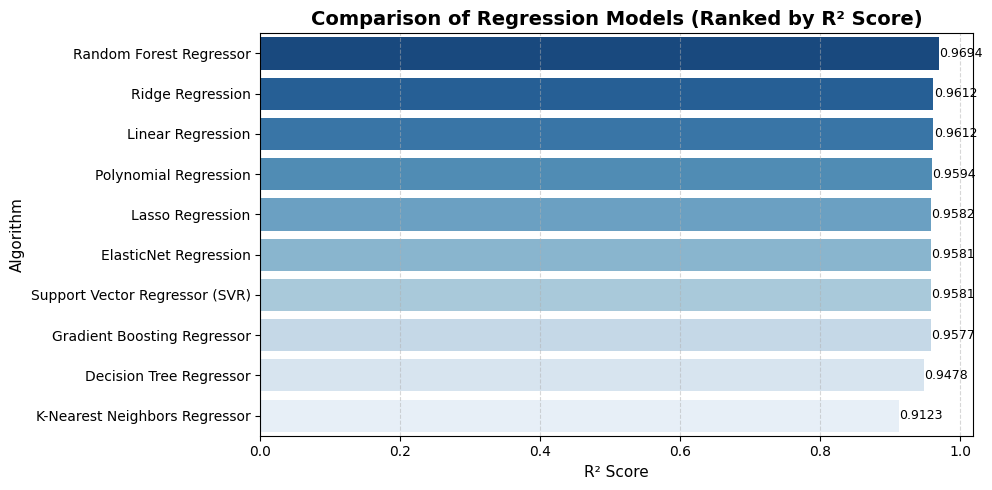

In [137]:
# REGRESSION MODEL COMPARISON BAR PLOT


plt.figure(figsize=(10, 5))

sns.barplot(
    data=regression_results,
    x='R2 Score',
    y='Algorithm',
    palette='Blues_r'
)

plt.title(
    'Comparison of Regression Models (Ranked by R² Score)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('R² Score', fontsize=11)
plt.ylabel('Algorithm', fontsize=11)

# Add R² score labels
for index, value in enumerate(regression_results['R2 Score']):
    plt.text(
        value + 0.0005,
        index,
        f'{value:.4f}',
        va='center',
        fontsize=9
    )

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [143]:
# ==========================================
# 5-FOLD CROSS VALIDATION - MODEL COMPARISON
# Random Forest vs Ridge Regression
# ==========================================

from sklearn.model_selection import cross_val_score
import pandas as pd

# Use a sample for faster cross-validation
CV_SAMPLE_SIZE = 10000

X_cv = X_train_reduced[:CV_SAMPLE_SIZE]
y_cv = y_train.iloc[:CV_SAMPLE_SIZE]

# ==========================================
# RANDOM FOREST - 5 FOLD CV
# ==========================================

cv_scores_rf = cross_val_score(
    rf_reg,
    X_cv,
    y_cv,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# ==========================================
# RIDGE REGRESSION - 5 FOLD CV
# ==========================================

cv_scores_ridge = cross_val_score(
    ridge,
    X_cv,
    y_cv,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# ==========================================
# CREATE COMPARISON TABLE
# ==========================================

cv_comparison = pd.DataFrame({
    'Model': [
        'Random Forest Regressor',
        'Ridge Regression'
    ],
    
    'Mean R² Score': [
        cv_scores_rf.mean(),
        cv_scores_ridge.mean()
    ],
    
    'Standard Deviation': [
        cv_scores_rf.std(),
        cv_scores_ridge.std()
    ],
    
    'Fold 1': [
        cv_scores_rf[0],
        cv_scores_ridge[0]
    ],
    
    'Fold 2': [
        cv_scores_rf[1],
        cv_scores_ridge[1]
    ],
    
    'Fold 3': [
        cv_scores_rf[2],
        cv_scores_ridge[2]
    ],
    
    'Fold 4': [
        cv_scores_rf[3],
        cv_scores_ridge[3]
    ],
    
    'Fold 5': [
        cv_scores_rf[4],
        cv_scores_ridge[4]
    ]
})

# Sort based on Mean R² Score
cv_comparison = cv_comparison.sort_values(
    by='Mean R² Score',
    ascending=False
).reset_index(drop=True)

# ==========================================
# DISPLAY RESULTS
# ==========================================

print("5-FOLD CROSS VALIDATION MODEL COMPARISON")

display(cv_comparison)

5-FOLD CROSS VALIDATION MODEL COMPARISON


,Model,Mean R² Score,Standard Deviation,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
0,Ridge Regression,0.955643,0.009202,0.940584,0.950511,0.966175,0.962994,0.957949
1,Random Forest Regressor,0.952441,0.014231,0.934896,0.953265,0.969870,0.966230,0.937945


### 5-Fold Cross-Validation Results

A 5-fold cross-validation was performed on the Random Forest Regressor using a sample of the training data for computational efficiency.

The model achieved a mean R² score of approximately **0.9524** with a standard deviation of **0.0142** across the five folds.

The relatively low variation in R² scores indicates that the Random Forest model demonstrates stable and consistent performance across different subsets of the data.

In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [47]:
# CLASSIFICATION DATA PREPARATION

# Find class boundaries using ONLY training target
q1 = y_train.quantile(0.33)
q2 = y_train.quantile(0.67)

# Create class labels using the same boundaries
bins = [-float('inf'), q1, q2, float('inf')]
labels = ['Low', 'Medium', 'High']

y_train_cls = pd.cut(
    y_train,
    bins=bins,
    labels=labels,
    include_lowest=True
)

y_test_cls = pd.cut(
    y_test,
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Use the same preprocessed features
X_train_cls = X_train_reduced
X_test_cls = X_test_reduced

print("Classification Class Distribution:")
print("\nTraining Data:")
print(y_train_cls.value_counts())

print("\nTest Data:")
print(y_test_cls.value_counts())

Classification Class Distribution:

Training Data:
fare_amount
Low       26359
Medium    24884
High      23640
Name: count, dtype: int64

Test Data:
fare_amount
Low       6606
Medium    6320
High      5795
Name: count, dtype: int64


In [49]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train
log_reg.fit(X_train_cls, y_train_cls)

# Predict
y_pred_lr = log_reg.predict(X_test_cls)

# Evaluate
lr_acc = accuracy_score(y_test_cls, y_pred_lr)
lr_f1 = f1_score(y_test_cls, y_pred_lr, average='weighted')
lr_prec = precision_score(y_test_cls, y_pred_lr, average='weighted')
lr_rec = recall_score(y_test_cls, y_pred_lr, average='weighted')

print("Model 1: Logistic Regression")
print(f"Accuracy: {lr_acc:.4f} | F1-Score: {lr_f1:.4f} | Precision: {lr_prec:.4f} | Recall: {lr_rec:.4f}")


Model 1: Logistic Regression
Accuracy: 0.9555 | F1-Score: 0.9555 | Precision: 0.9555 | Recall: 0.9555


In [101]:
# ==========================================
# KNN CLASSIFIER - FEATURE SCALING
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler_knn_cls = StandardScaler()

X_train_knn_scaled = scaler_knn_cls.fit_transform(X_train_cls)
X_test_knn_scaled = scaler_knn_cls.transform(X_test_cls)

In [102]:
# ==========================================
# KNN CLASSIFIER - K VALUE TUNING
# ==========================================

from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

# Use reduced training sample for faster computation
sample_size = 20000

X_train_knn_tune = X_train_knn_scaled[:sample_size]
y_train_knn_tune = y_train_cls.iloc[:sample_size]

# K values to test
k_values = [3, 5, 7, 9]

results = []

for k in k_values:

    model = KNeighborsClassifier(
        n_neighbors=k,
        weights='distance',
        n_jobs=-1
    )

    # Train
    model.fit(X_train_knn_tune, y_train_knn_tune)

    # Predict
    predictions = model.predict(X_test_knn_scaled)

    # Store results
    results.append({
        'K Value': k,
        'Accuracy': accuracy_score(y_test_cls, predictions),
        'F1 Score': f1_score(
            y_test_cls,
            predictions,
            average='weighted',
            zero_division=0
        ),
        'Precision': precision_score(
            y_test_cls,
            predictions,
            average='weighted',
            zero_division=0
        ),
        'Recall': recall_score(
            y_test_cls,
            predictions,
            average='weighted',
            zero_division=0
        )
    })

knn_tuning_results = pd.DataFrame(results)

knn_tuning_results = knn_tuning_results.sort_values(
    by='Accuracy',
    ascending=False
).reset_index(drop=True)

print("KNN Classifier K Value Tuning Results")
display(knn_tuning_results)

KNN Classifier K Value Tuning Results


,K Value,Accuracy,F1 Score,Precision,Recall
0,7,0.737941,0.737492,0.737790,0.737941
1,9,0.737140,0.736345,0.736271,0.737140
2,5,0.735324,0.734973,0.735238,0.735324
3,3,0.731852,0.731634,0.731932,0.731852


In [105]:
# MODEL 2: K-NEAREST NEIGHBORS CLASSIFIER

from sklearn.neighbors import KNeighborsClassifier

# Best K value selected from tuning
best_k = 7

# Use reduced training sample
sample_size = 20000

X_train_knn = X_train_knn_scaled[:sample_size]
y_train_knn = y_train_cls.iloc[:sample_size]

# Create model
knn_cls = KNeighborsClassifier(
    n_neighbors=best_k,
    weights='distance',
    n_jobs=-1
)

# Train
knn_cls.fit(X_train_knn, y_train_knn)

# Predict
y_pred_knn = knn_cls.predict(X_test_knn_scaled)

# Evaluate
knn_acc = accuracy_score(y_test_cls, y_pred_knn)

knn_f1 = f1_score(
    y_test_cls,
    y_pred_knn,
    average='weighted',
    zero_division=0
)

knn_prec = precision_score(
    y_test_cls,
    y_pred_knn,
    average='weighted',
    zero_division=0
)

knn_rec = recall_score(
    y_test_cls,
    y_pred_knn,
    average='weighted',
    zero_division=0
)

print("Model 2: K-Nearest Neighbors Classifier")
print(f"Best K Value: {best_k}")
print(f"Training Sample Size: {sample_size}")
print(
    f"Accuracy: {knn_acc:.4f} | "
    f"F1-Score: {knn_f1:.4f} | "
    f"Precision: {knn_prec:.4f} | "
    f"Recall: {knn_rec:.4f}"
)

Model 2: K-Nearest Neighbors Classifier
Best K Value: 7
Training Sample Size: 20000
Accuracy: 0.7379 | F1-Score: 0.7375 | Precision: 0.7378 | Recall: 0.7379


In [51]:
# Gaussian Naive Bayes


from sklearn.naive_bayes import GaussianNB

# Create and train the model
gnb = GaussianNB()
gnb.fit(X_train_cls, y_train_cls)

# Predict
y_pred_gnb = gnb.predict(X_test_cls)

# Evaluate
gnb_acc = accuracy_score(y_test_cls, y_pred_gnb)
gnb_f1 = f1_score(
    y_test_cls,
    y_pred_gnb,
    average='weighted',
    zero_division=0
)
gnb_prec = precision_score(
    y_test_cls,
    y_pred_gnb,
    average='weighted',
    zero_division=0
)
gnb_rec = recall_score(
    y_test_cls,
    y_pred_gnb,
    average='weighted',
    zero_division=0
)

# Display results
print("Model 3: Gaussian Naive Bayes")
print(
    f"Accuracy: {gnb_acc:.4f} | "
    f"F1-Score: {gnb_f1:.4f} | "
    f"Precision: {gnb_prec:.4f} | "
    f"Recall: {gnb_rec:.4f}"
)

Model 3: Gaussian Naive Bayes
Accuracy: 0.7863 | F1-Score: 0.7873 | Precision: 0.7909 | Recall: 0.7863


In [55]:
#Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
dt_cls = DecisionTreeClassifier(
    max_depth=10,
    random_state=RANDOM_STATE
)

# Train
dt_cls.fit(X_train_cls, y_train_cls)

# Predict
y_pred_dt = dt_cls.predict(X_test_cls)

# Evaluate
dt_acc = accuracy_score(y_test_cls, y_pred_dt)

dt_f1 = f1_score(
    y_test_cls,
    y_pred_dt,
    average='weighted',
    zero_division=0
)

dt_prec = precision_score(
    y_test_cls,
    y_pred_dt,
    average='weighted',
    zero_division=0
)

dt_rec = recall_score(
    y_test_cls,
    y_pred_dt,
    average='weighted',
    zero_division=0
)

print("Model 4: Decision Tree Classifier")
print(
    f"Accuracy: {dt_acc:.4f} | "
    f"F1-Score: {dt_f1:.4f} | "
    f"Precision: {dt_prec:.4f} | "
    f"Recall: {dt_rec:.4f}"
)

Model 4: Decision Tree Classifier
Accuracy: 0.9480 | F1-Score: 0.9480 | Precision: 0.9482 | Recall: 0.9480


In [98]:
# ==========================================
# SVC FEATURE SCALING
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler_svc = StandardScaler()

X_train_svc_scaled = scaler_svc.fit_transform(X_train_cls)
X_test_svc_scaled = scaler_svc.transform(X_test_cls)

In [99]:
# ==========================================
# SVC - TUNE C AND KERNEL
# ==========================================

from sklearn.svm import SVC
import pandas as pd

SAMPLE_SIZE = 3000

X_train_svc_sample = X_train_svc_scaled[:SAMPLE_SIZE]
y_train_svc_sample = y_train_cls.iloc[:SAMPLE_SIZE]

C_values = [0.1, 1, 10]
kernels = ['linear', 'rbf']

results = []

for kernel in kernels:
    for C in C_values:

        model = SVC(
            kernel=kernel,
            C=C,
            random_state=RANDOM_STATE
        )

        model.fit(X_train_svc_sample, y_train_svc_sample)

        predictions = model.predict(X_test_svc_scaled)

        results.append({
            'Kernel': kernel,
            'C': C,
            'Accuracy': accuracy_score(y_test_cls, predictions),
            'Weighted F1': f1_score(
                y_test_cls,
                predictions,
                average='weighted',
                zero_division=0
            )
        })

svc_tuning_results = pd.DataFrame(results)

svc_tuning_results = svc_tuning_results.sort_values(
    by='Accuracy',
    ascending=False
).reset_index(drop=True)

display(svc_tuning_results)

,Kernel,C,Accuracy,Weighted F1
0,linear,10.0,0.939693,0.939730
1,linear,1.0,0.934779,0.934755
2,linear,0.1,0.913466,0.913728
3,rbf,10.0,0.817638,0.818334
4,rbf,1.0,0.791250,0.793959
5,rbf,0.1,0.526254,0.451127


In [100]:
# MODEL 5: SUPPORT VECTOR CLASSIFIER (SVC)

from sklearn.svm import SVC

# Use reduced training sample because SVC is computationally expensive
SAMPLE_SIZE = 5000

X_train_svc = X_train_svc_scaled[:SAMPLE_SIZE]
y_train_svc = y_train_cls.iloc[:SAMPLE_SIZE]

# Best configuration selected from tuning
svc_cls = SVC(
    kernel='linear',
    C=10.0,
    random_state=RANDOM_STATE
)

# Train
svc_cls.fit(X_train_svc, y_train_svc)

# Predict
y_pred_svc = svc_cls.predict(X_test_svc_scaled)

# Evaluate
svc_acc = accuracy_score(y_test_cls, y_pred_svc)
svc_f1 = f1_score(
    y_test_cls,
    y_pred_svc,
    average='weighted',
    zero_division=0
)
svc_prec = precision_score(
    y_test_cls,
    y_pred_svc,
    average='weighted',
    zero_division=0
)
svc_rec = recall_score(
    y_test_cls,
    y_pred_svc,
    average='weighted',
    zero_division=0
)

print("Model 5: Support Vector Classifier (SVC)")
print("Best Kernel: Linear")
print("Best C: 10.0")
print(f"Training Sample Size: {SAMPLE_SIZE}")
print(
    f"Accuracy: {svc_acc:.4f} | "
    f"F1-Score: {svc_f1:.4f} | "
    f"Precision: {svc_prec:.4f} | "
    f"Recall: {svc_rec:.4f}"
)

Model 5: Support Vector Classifier (SVC)
Best Kernel: Linear
Best C: 10.0
Training Sample Size: 5000
Accuracy: 0.9466 | F1-Score: 0.9466 | Precision: 0.9465 | Recall: 0.9466


In [106]:
member3_results = pd.DataFrame({
    'Algorithm': [
        'Logistic Regression',
        'K-Nearest Neighbors Classifier',
        'Gaussian Naive Bayes',
        'Decision Tree Classifier',
        'Support Vector Classifier (SVC)'
    ],
    
    'Accuracy': [lr_acc, knn_acc, gnb_acc, dt_acc, svc_acc],
    'Weighted F1': [lr_f1, knn_f1, gnb_f1, dt_f1, svc_f1],
    'Precision': [lr_prec, knn_prec, gnb_prec, dt_prec, svc_prec],
    'Recall': [lr_rec, knn_rec, gnb_rec, dt_rec, svc_rec]
})

# Sort models by Accuracy
member3_results = member3_results.sort_values(
    by='Accuracy',
    ascending=False
).reset_index(drop=True)

# Display as a normal Jupyter table
member3_results

,Algorithm,Accuracy,Weighted F1,Precision,Recall
0,Logistic Regression,0.955505,0.955501,0.955524,0.955505
1,Decision Tree Classifier,0.947973,0.948042,0.948196,0.947973
2,Support Vector Classifier (SVC),0.946584,0.946560,0.946543,0.946584
3,Gaussian Naive Bayes,0.786336,0.787317,0.790903,0.786336
4,K-Nearest Neighbors Classifier,0.737941,0.737492,0.737790,0.737941


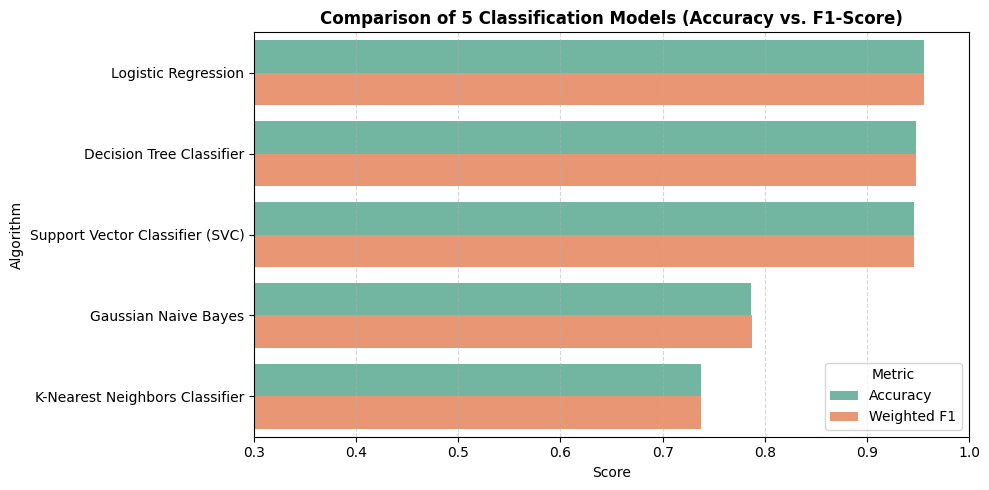

In [109]:
#Classification Model Comparison Bar Plot


import matplotlib.pyplot as plt
import seaborn as sns

# Reshape results for Accuracy vs Weighted F1 comparison
classification_melted = member3_results.melt(
    id_vars=['Algorithm'],
    value_vars=['Accuracy', 'Weighted F1'],
    var_name='Metric',
    value_name='Score'
)

# Create normal-sized figure
plt.figure(figsize=(10, 5))

sns.barplot(
    data=classification_melted,
    x='Score',
    y='Algorithm',
    hue='Metric',
    palette='Set2'
)

plt.title(
    'Comparison of 5 Classification Models (Accuracy vs. F1-Score)',
    fontsize=12,
    fontweight='bold'
)

plt.xlabel('Score')
plt.ylabel('Algorithm')

plt.xlim(0.3, 1.0)

plt.legend(
    title='Metric',
    loc='lower right'
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()
plt.show()

In [144]:
# ==========================================
# 5-FOLD CROSS VALIDATION - TOP 2 CLASSIFIERS
# Logistic Regression vs Decision Tree
# ==========================================

from sklearn.model_selection import cross_val_score
import pandas as pd

# Use the same training data for both models
X_cv_cls = X_train_cls
y_cv_cls = y_train_cls


# ==========================================
# LOGISTIC REGRESSION - 5 FOLD CV
# ==========================================

cv_scores_log = cross_val_score(
    log_reg,
    X_cv_cls,
    y_cv_cls,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)


# ==========================================
# DECISION TREE - 5 FOLD CV
# ==========================================

cv_scores_dt_cls = cross_val_score(
    dt_cls,
    X_cv_cls,
    y_cv_cls,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)


# ==========================================
# CREATE COMPARISON TABLE
# ==========================================

cv_classification_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree Classifier'
    ],

    'Mean Accuracy': [
        cv_scores_log.mean(),
        cv_scores_dt_cls.mean()
    ],

    'Standard Deviation': [
        cv_scores_log.std(),
        cv_scores_dt_cls.std()
    ],

    'Fold 1': [
        cv_scores_log[0],
        cv_scores_dt_cls[0]
    ],

    'Fold 2': [
        cv_scores_log[1],
        cv_scores_dt_cls[1]
    ],

    'Fold 3': [
        cv_scores_log[2],
        cv_scores_dt_cls[2]
    ],

    'Fold 4': [
        cv_scores_log[3],
        cv_scores_dt_cls[3]
    ],

    'Fold 5': [
        cv_scores_log[4],
        cv_scores_dt_cls[4]
    ]
})

# Sort by Mean Accuracy
cv_classification_comparison = (
    cv_classification_comparison
    .sort_values(
        by='Mean Accuracy',
        ascending=False
    )
    .reset_index(drop=True)
)


# ==========================================
# DISPLAY RESULTS
# ==========================================

print("5-FOLD CROSS VALIDATION - CLASSIFICATION MODEL COMPARISON")

display(cv_classification_comparison)

5-FOLD CROSS VALIDATION - CLASSIFICATION MODEL COMPARISON


,Model,Mean Accuracy,Standard Deviation,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
0,Logistic Regression,0.956318,0.001615,0.956533,0.957401,0.956800,0.953192,0.957666
1,Decision Tree Classifier,0.947505,0.001432,0.947052,0.948922,0.945984,0.946114,0.949452


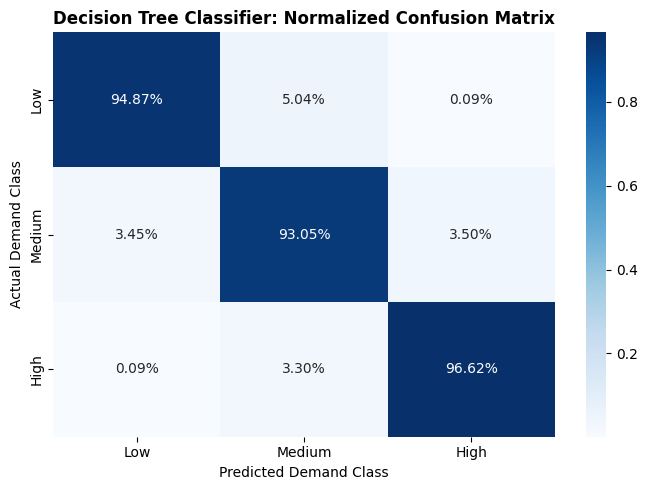

In [112]:
#Confusion Matrix Heatmap (Top Classifier: Decision Tree)

from sklearn.metrics import confusion_matrix

# Generate classifier predictions
y_pred_dt_cls = dt_cls.predict(X_test_cls)

# Compute confusion matrix
cm = confusion_matrix(
    y_test_cls,
    y_pred_dt_cls,
    labels=['Low', 'Medium', 'High']
)

# Normalize row-wise
cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# Plot
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_percent,
    annot=True,
    fmt='.2%',
    cmap='Blues',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)

plt.title(
    'Decision Tree Classifier: Normalized Confusion Matrix',
    fontsize=12,
    fontweight='bold'
)

plt.xlabel('Predicted Demand Class')
plt.ylabel('Actual Demand Class')

plt.tight_layout()
plt.show()